In [3]:
from mlwpy import *
%matplotlib inline

# Load the Iris dataset
iris = datasets.load_iris()

# Split into training and testing sets
(iris_train, iris_test,
 iris_train_tgt, iris_test_tgt) = skms.train_test_split(
    iris.data, iris.target, test_size=0.25
)

# Remove units (' (cm)') from feature names
iris.feature_names = [fn[:-5] for fn in iris.feature_names]

# Create a DataFrame for convenience
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]


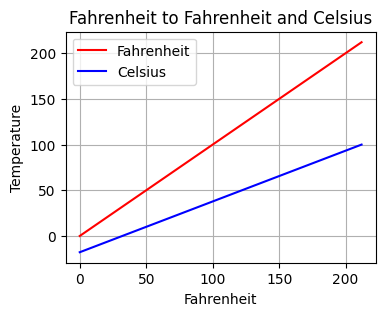

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

f_temps = np.linspace(0, 212, 100)
c_temps = (5/9) * (f_temps - 32)

# Plot Fahrenheit vs Fahrenheit and Fahrenheit vs Celsius
plt.plot(f_temps, f_temps, 'r', label='Fahrenheit')
plt.plot(f_temps, c_temps, 'b', label='Celsius')
plt.legend()
plt.xlabel("Fahrenheit")
plt.ylabel("Temperature")
plt.title("Fahrenheit to Fahrenheit and Celsius")
plt.grid(True)
plt.show()


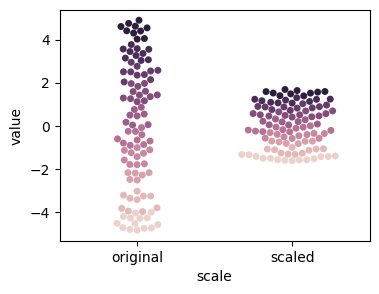

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Generate random values and scale them
original = np.random.uniform(-5, 5, 100)
scaled = skpre.StandardScaler().fit_transform(original.reshape(-1, 1))[:, 0]

# Create hue bins based on original values
bins = np.floor(original).astype(np.uint8) + 5

# Construct DataFrame
df = pd.DataFrame({
    'original': original,
    'scaled': scaled,
    'hue': bins
})

# Melt for seaborn plotting
df = pd.melt(df, id_vars='hue', var_name='scale')

# Plot
sns.swarmplot(x='scale', y='value', hue='hue', data=df)
plt.legend().remove()


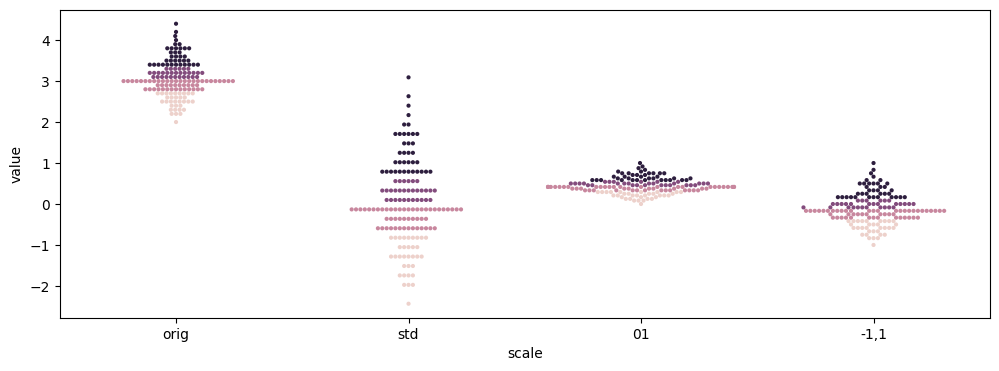

In [13]:
# Set categorical color palette to match textbook hue styling
sns.set_palette('tab10')

# Use wider figure to prevent overlap and mimic textbook proportions
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Create base DataFrame from iris sepal width
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
bins = pd.cut(
    iris_df['sepal width'],
    np.percentile(iris_df['sepal width'], [25, 50, 75, 100]),
    include_lowest=True
).cat.codes

df = pd.DataFrame({
    'orig': iris_df['sepal width'],
    'hue': bins
})

# Define scalers and apply each
scalers = [
    ('std', skpre.StandardScaler()),
    ('01', skpre.MinMaxScaler()),
    ('-1,1', skpre.MinMaxScaler((-1, 1)))
]

for name, scaler in scalers:
    df[name] = scaler.fit_transform(df[['orig']]).reshape(-1)

# Reshape for plotting
df = pd.melt(df, id_vars='hue', var_name='scale')

# Final plot with small markers and categorical color hue
sns.swarmplot(x='scale', y='value', hue='hue', data=df, size=3).legend_.remove()


In [14]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

# Display one sample from each Iris species
display(iris_df.iloc[[0, 50, 100]])


,sepal length,sepal width,petal length,petal width,species
0,5.1000,3.5000,1.4000,0.2000,setosa
50,7.0000,3.2000,4.7000,1.4000,versicolor
100,6.3000,3.3000,6.0000,2.5000,virginica


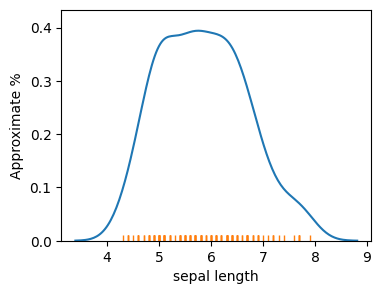

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
sns.kdeplot(data=iris_df, x='sepal length', ax=ax)
sns.rugplot(data=iris_df, x='sepal length', ax=ax)
ax.set_ylabel("Approximate %")
plt.show()


In [22]:
# Keep 2D structure for sklearn compatibility
column = iris_df[['sepal length']]

# Compute column mean (as scalar value)
col_mean = column.mean().values  # returns array of shape (1,)

# Make a copy and apply binary thresholding
both = column.copy()
both['> Mean'] = skpre.binarize(column, threshold=col_mean[0]).astype(bool)

# Output
print('Column Mean:', col_mean)
display(both.iloc[[0, 50, 100]])


Column Mean: [5.8433]


,sepal length,> Mean
0,5.1000,False
50,7.0000,True
100,6.3000,True


In [24]:
sep_len_series = iris_df['sepal length']
breaks = [sep_len_series.mean(), sep_len_series.max()]
print(pd.cut(sep_len_series, breaks).cat.codes[[0, 50, 100]])


0     -1
50     0
100    0
dtype: int8


In [25]:
# Select and reorder the desired columns: input features first, then target
new_iris_df = pd.DataFrame(iris_df, columns=[
    'petal width', 'species', 'petal length'
])

# Assign MultiIndex to columns
new_iris_df.columns = pd.MultiIndex.from_arrays(
    [['input ftrs', 'input ftrs', 'target ftr'],
     ['petal width', 'species', 'petal length']],
    names=['feature type', 'feature name']
)

# Sort to group by outer level ("feature type")—not strictly required
new_iris_df.sort_index(axis='columns', inplace=True)

# Display one row from each species
display(new_iris_df.iloc[[0, 50, 100]])


feature type           input ftrs                       target ftr
feature name          petal width     species         petal length
0                          0.2000      setosa               1.4000
50                         1.4000  versicolor               4.7000
100                        2.5000   virginica               6.0000

In [26]:
# Start with category numbers
print("Numerical categories:",
      iris.target[[0, 50, 100]],
      sep='\n')

# One-hot encode the category numbers (sparse by default)
sparse = skpre.OneHotEncoder().fit_transform(iris.target.reshape(-1, 1))

# Convert selected rows to dense format for readability
print("One-hot coding:",
      sparse[[0, 50, 100]].todense(),
      sep="\n")


Numerical categories:
[0 1 2]
One-hot coding:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [27]:
# can use drop_first to get treatment coding
# can request sparse storage
encoded = pd.get_dummies(iris_df, prefix="is")
encoded.iloc[[0,50,100]]

,sepal length,sepal width,petal length,petal width,is_setosa,is_versicolor,is_virginica
0,5.1000,3.5000,1.4000,0.2000,True,False,False
50,7.0000,3.2000,4.7000,1.4000,False,True,False
100,6.3000,3.3000,6.0000,2.5000,False,False,True


In [28]:
# splicing dataframes together by merging
# recall `iris.target` is in terms of 0, 1, 2, not symbolic (setosa, etc).
encoded_species = pd.get_dummies(iris.target)
encoded_df = pd.merge(iris_df, encoded_species,
right_index=True, left_index=True)
encoded_df.iloc[[0,50,100]]

,sepal length,sepal width,petal length,petal width,species,0,1,2
0,5.1000,3.5000,1.4000,0.2000,setosa,True,False,False
50,7.0000,3.2000,4.7000,1.4000,versicolor,False,True,False
100,6.3000,3.3000,6.0000,2.5000,virginica,False,False,True


In [29]:
import patsy.contrasts as pc
levels = iris.target_names
coding = (pc.Treatment(reference=0)
.code_with_intercept(list(levels)))
print(coding)

ContrastMatrix(array([[1., 0., 0.],
                      [0., 1., 0.],
                      [0., 0., 1.]]),
               ['[setosa]', '[versicolor]', '[virginica]'])


In [30]:
encoded = patsy.dmatrix('species',
iris_df,
return_type='dataframe')
display(encoded.iloc[[0,50,100]])

,Intercept,species[T.versicolor],species[T.virginica]
0,1.0000,0.0000,0.0000
50,1.0000,1.0000,0.0000
100,1.0000,0.0000,1.0000


In [31]:
pet_data = pd.DataFrame({'pet' :['cat', 'cat', 'dog'],
'cost':[20.0, 25.0, 40.0]})
pet_df = pd.get_dummies(pet_data)
display(pet_df)

,cost,pet_cat,pet_dog
0,20.0000,True,False
1,25.0000,True,False
2,40.0000,False,True


In [34]:
def pretty_coeffs(sk_lr_model, ftr_names):
    '''Helper to display sklearn results in a nice dataframe'''
    lr_coeffs = pd.DataFrame(sk_lr_model.coef_,
                             columns=ftr_names,
                             index=['Coeff'])
    lr_coeffs['intercept'] = sk_lr_model.intercept_
    return lr_coeffs


In [35]:
# massage
sk_tgt = pet_df['cost'].values.reshape(-1,1)
sk_ftrs = pet_df.drop('cost', axis='columns')
# build model
sk_model = (linear_model.LinearRegression(fit_intercept=False)
.fit(sk_ftrs, sk_tgt))
display(pretty_coeffs(sk_model, sk_ftrs.columns))

,pet_cat,pet_dog,intercept
Coeff,22.5000,40.0000,0.0000


In [37]:
import statsmodels as sm
import statsmodels.formula.api as smf

In [38]:
# patsy formula that explicitly removes an intercept
formula = 'cost ~ pet - 1'
sm_model = smf.ols(formula, data=pet_data).fit()
display(pd.DataFrame(sm_model.params).T)

,pet[cat],pet[dog]
0,22.5000,40.0000


In [39]:
sk_tgt = pet_df['cost'].values.reshape(-1,1)
sk_ftrs = pet_df.drop('cost', axis='columns')
sk_model = (linear_model.LinearRegression() # fit_intercept=True by default!
.fit(sk_ftrs, sk_tgt))
display(pretty_coeffs(sk_model, sk_ftrs.columns))

,pet_cat,pet_dog,intercept
Coeff,-8.7500,8.7500,31.2500


In [40]:
pet_data_p1 = pet_data.copy() # don't muck the original data
pet_data_p1['ones'] = 1.0 # manual +1 trick
# remove coding intercept ..... add manual ones == add manual intercept
formula = 'cost ~ (pet - 1) + ones'
sm_model = smf.ols(formula, data=pet_data_p1).fit()
display(pd.DataFrame(sm_model.params).T)

,pet[cat],pet[dog],ones
0,1.6667,19.1667,20.8333


In [41]:
# row-slicing is annoying, but have to get to single-D things
# and .flat gives a warning in the DF constructor
df = pd.DataFrame({'predicted_sk' : sk_model.predict(sk_ftrs)[:,0],
'predicted_sm' : sm_model.predict(pet_data_p1),
'actual' : sk_tgt[:,0]})
display(df)

,predicted_sk,predicted_sm,actual
0,22.5000,22.5000,20.0000
1,22.5000,22.5000,25.0000
2,40.0000,40.0000,40.0000


In [42]:
display(pet_data_p1)

,pet,cost,ones
0,cat,20.0000,1.0000
1,cat,25.0000,1.0000
2,dog,40.0000,1.0000


In [43]:
print('pet - 1 coding')
print(patsy.dmatrix('pet - 1', data=pet_data_p1))

pet - 1 coding
[[1. 0.]
 [1. 0.]
 [0. 1.]]


In [44]:
print('pet - 1 coding')
print(patsy.dmatrix('pet - 1', data=pet_data_p1))

pet - 1 coding
[[1. 0.]
 [1. 0.]
 [0. 1.]]


In [45]:
xor_data = [[0,0,0],
[0,1,1],
[1,0,1],
[1,1,0]]

In [49]:
import pandas as pd
from sklearn import linear_model

# Define the XOR dataset
xor_df = pd.DataFrame({
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    'tgt': [0, 1, 1, 0]  # XOR truth table
})

# Fit logistic regression model
model = linear_model.LogisticRegression().fit(xor_df[['x1', 'x2']], xor_df['tgt'])

# Predict and display results
preds = model.predict(xor_df[['x1', 'x2']])
print("Predictions:", preds)


Predictions: [0 0 0 0]


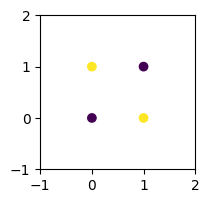

In [50]:
fig, ax = plt.subplots(1,1,figsize=(2,2))
ax.scatter('x1', 'x2', data=xor_df, c='tgt')
ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2);

In [51]:
xor_df['new'] = (-1)**xor_df['x1'] * (-1)**xor_df['x2']
xor_df

,x1,x2,tgt,new
0,0,0,0,1
1,0,1,1,-1
2,1,0,1,-1
3,1,1,0,1


In [52]:
model = linear_model.LogisticRegression().fit(xor_df[['new']],
xor_df['tgt'])
model.predict(xor_df[['new']])

array([0, 1, 1, 0], dtype=int64)

In [55]:
# Define interaction-only polynomial transformer
quad_inters = skpre.PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

# Select subset of rows and features
subset = iris_df.loc[[0, 50, 100], ['sepal length', 'sepal width']]

# Generate interaction features
new_terms = pd.DataFrame(
    quad_inters.fit_transform(subset),
    index=[0, 50, 100]
)

# Rename columns
new_terms = new_terms.set_axis(['sep length', 'sep width', 'sep area'], axis=1)

# Display result
display(new_terms)


,sep length,sep width,sep area
0,5.1000,3.5000,17.8500
50,7.0000,3.2000,22.4000
100,6.3000,3.3000,20.7900


In [56]:
design_df = patsy.dmatrix("Q('sepal length'):Q('sepal width') - 1",
data=iris_df.iloc[[0, 50, 100]],
return_type='dataframe')
design_df

,Q('sepal length'):Q('sepal width')
0,17.8500
50,22.4000
100,20.7900


In [57]:
sepal_area = iris_df['sepal length'] * iris_df['sepal width']
petal_area = iris_df['petal length'] * iris_df['petal width']
# discretize
iris_df['big_sepal'] = sepal_area > sepal_area.median()
iris_df['big_petal'] = petal_area > petal_area.median()
display(iris_df.iloc[[0,50,100]])

,sepal length,sepal width,petal length,petal width,species,big_sepal,big_petal
0,5.1000,3.5000,1.4000,0.2000,setosa,True,False
50,7.0000,3.2000,4.7000,1.4000,versicolor,True,True
100,6.3000,3.3000,6.0000,2.5000,virginica,True,True


In [58]:
design_df = patsy.dmatrix("big_sepal:big_petal - 1",
data=iris_df.iloc[[0, 50, 100]],
return_type='dataframe')
# breaking up the long column names
display(design_df.iloc[:, :2])
display(design_df.iloc[:,2: ])

,big_sepal[False]:big_petal[False],big_sepal[True]:big_petal[False]
0,0.0000,1.0000
50,0.0000,0.0000
100,0.0000,0.0000


,big_sepal[False]:big_petal[True],big_sepal[True]:big_petal[True]
0,0.0000,0.0000
50,0.0000,1.0000
100,0.0000,1.0000


In [59]:
# we (Q)uote sepal length because it has a space in the name
design_df = patsy.dmatrix("C(species,Treatment):Q('sepal length') - 1",
data=iris_df.iloc[[0, 50, 100]],
return_type='dataframe')
# breaking up the long column names
display(design_df.iloc[:,[0]])
display(design_df.iloc[:,[1]])
display(design_df.iloc[:,[2]])

,"C(species, Treatment)[setosa]:Q('sepal length')"
0,5.1000
50,0.0000
100,0.0000


,"C(species, Treatment)[versicolor]:Q('sepal length')"
0,0.0000
50,7.0000
100,0.0000


,"C(species, Treatment)[virginica]:Q('sepal length')"
0,0.0000
50,0.0000
100,6.3000


In [60]:
print(iris_df.iloc[[0, 50, 100]]['sepal length'])

0                   5.1000
50                  7.0000
100                 6.3000
Name: sepal length, dtype: float64


In [62]:
import patsy
from sklearn import linear_model

# Define the interaction design matrix using treatment coding
design = "C(species, Treatment):petal_area"
design_matrix = patsy.dmatrix(design, data=iris_df)

# Fit a linear regression model using the design matrix
lr = linear_model.LinearRegression(fit_intercept=False)
mod = lr.fit(design_matrix, iris_df['sepal width'])

# Display model coefficients
print(mod.coef_)


[ 2.8378  1.402  -0.0034  0.0146]


In [63]:
# hey, we get the same results!
formula = "Q('sepal width') ~ C(species,Treatment):petal_area"
res1 = smf.ols(formula=formula, data=iris_df).fit()
print(res1.params)

Intercept                                                    2.8378
C(species, Treatment)[setosa]:petal_area                     1.4020
C(species, Treatment)[versicolor]:petal_area                -0.0034
C(species, Treatment)[virginica]:petal_area                  0.0146
dtype: float64


In [64]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
area_df = pd.DataFrame({"sepal_area" : iris_df['sepal length'] *
iris_df['sepal width'],
"petal_area" : iris_df['petal length'] *
iris_df['petal width']})

In [71]:
import numpy as np
import pandas as pd
from sklearn import preprocessing as skpre

# Recreate iris_df and add species labels
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

# Create area_df with two derived features
area_df = pd.DataFrame({
    "sepal_area": iris_df['sepal length'] * iris_df['sepal width'],
    "petal_area": iris_df['petal length'] * iris_df['petal width']
})

# Define binary threshold function
def median_big_small(d):
    return d > np.median(d)

# Apply FunctionTransformer
transformer = skpre.FunctionTransformer(median_big_small)
res = transformer.fit_transform(area_df)

# Convert result to DataFrame for clearer indexing
res_df = pd.DataFrame(res, columns=area_df.columns)

# Display selected rows
print("Large areas as compared to median?")
print(res_df.iloc[[0, 50, 100]])


Large areas as compared to median?
     sepal_area  petal_area
0          True       False
50         True       False
100        True        True


In [74]:
def median_big_small(d):
    return d > np.median(d)

transformer = skpre.FunctionTransformer(median_big_small)
res = transformer.fit_transform(area_df)

# Convert to DataFrame for consistent row indexing
res_df = pd.DataFrame(res, columns=area_df.columns)

print("Large areas as compared to median?")
print(res_df.iloc[[0, 50, 100]])


Large areas as compared to median?
     sepal_area  petal_area
0          True       False
50         True       False
100        True        True


In [76]:
from sklearn.base import TransformerMixin
from sklearn import model_selection as skms
import numpy as np
import pandas as pd

# Rebuild area_df if not already defined
area_df = pd.DataFrame({
    "sepal_area": iris_df['sepal length'] * iris_df['sepal width'],
    "petal_area": iris_df['petal length'] * iris_df['petal width']
})

# Define custom transformer
class Median_Big_Small(TransformerMixin):
    def __init__(self):
        pass

    def fit(self, ftrs, tgt=None):
        self.medians = np.median(ftrs, axis=0)
        return self

    def transform(self, ftrs, tgt=None):
        return ftrs > self.medians

# Train-test split
training, testing = skms.train_test_split(area_df)

# Apply custom transformer
transformer = Median_Big_Small()
train_xform = transformer.fit_transform(training)
test_xform = transformer.transform(testing)

# Display transformed results
print('train:')
display(pd.DataFrame(train_xform, columns=area_df.columns).head(3))
print('test:')
display(pd.DataFrame(test_xform, columns=area_df.columns).head(3))


train:


,sepal_area,petal_area
10,True,False
62,False,False
79,False,False


test:


,sepal_area,petal_area
53,False,False
91,True,True
35,False,False


In [77]:
x = np.linspace(1,10,50)
n1 = np.random.normal(size=x.shape)
comparison = pd.DataFrame({"x" : x,
"d1" : 2*x+5 + n1,
"d2" : 2*x**2+5 + n1})
comparison['x'] = x
melted = pd.melt(comparison, id_vars=['x'])

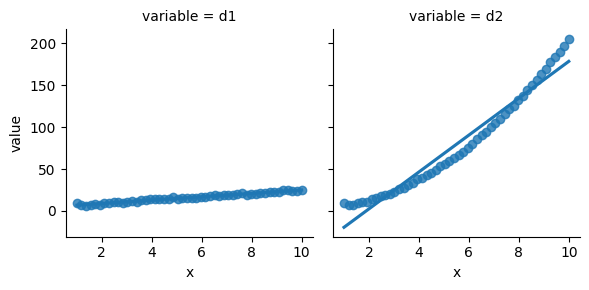

In [79]:
sns.lmplot(x='x', y='value',
           data=melted, col='variable', ci=None,
           height=3)


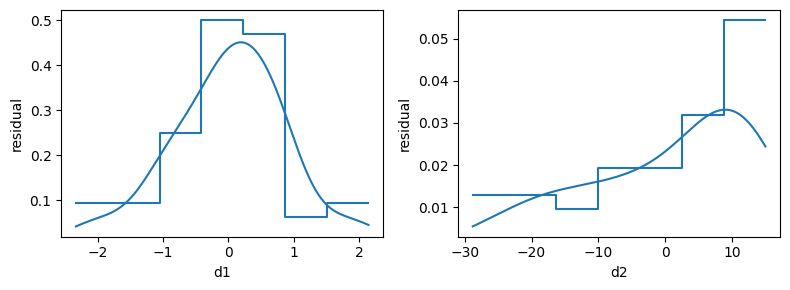

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, variable in zip(axes, ['d1', 'd2']):
    predicted = (
        smf.ols(f"{variable} ~ x", data=comparison)
        .fit()
        .predict()
    )
    actual = comparison[variable]
    residuals = predicted - actual

    # Use histplot or kdeplot instead of distplot
    sns.histplot(residuals, kde=True, stat="density", ax=ax, element="step", fill=False)
    ax.set_xlabel(variable)
    ax.set_ylabel("residual")

fig.tight_layout()


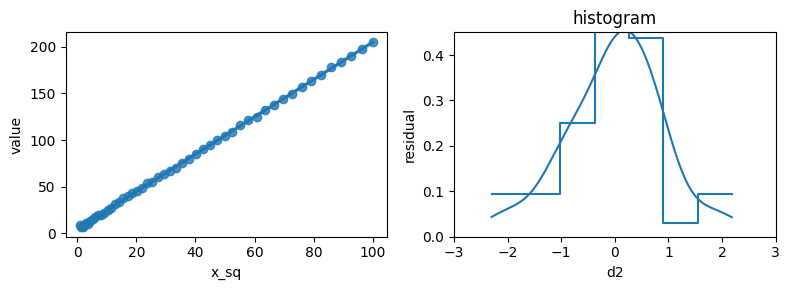

In [81]:
# Create the DataFrame
magic = pd.DataFrame({
    "d2": 2 * x**2 + 5 + n1,
    "x_sq": x**2
})

# Melt the DataFrame for plotting
melted = pd.melt(magic, id_vars=['x_sq'])

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# First plot: regression line on melted data
sns.regplot(x='x_sq', y='value', data=melted, ci=None, ax=ax1)

# Linear model fit
predicted = smf.ols("d2 ~ x_sq", data=magic).fit().predict()
actual = magic['d2']  # FIX: Use 'magic', not 'comparison'
residuals = predicted - actual

# Second plot: residuals histogram
sns.histplot(residuals, kde=True, stat="density", ax=ax2, element="step", fill=False)
ax2.set_title('histogram')
ax2.set_xlim(-3, 3)
ax2.set_ylim(0, 0.45)
ax2.set_ylabel('residual')

fig.tight_layout()


In [83]:
x = np.linspace(1,10,50)
n1 = np.random.normal(size=x.shape)
n2 = .5*x*np.random.normal(size=x.shape)
comparison = pd.DataFrame({"x" : x,
"d1" : 2*x+5+n1,
"d2" : 2*x+5+n2})
comparison['x'] = x
melted = pd.melt(comparison, id_vars=['x'])

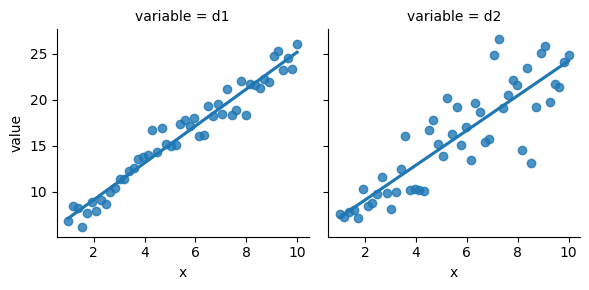

In [85]:
sns.lmplot(x='x', y='value',
           data=melted, col='variable', ci=None,
           height=3);


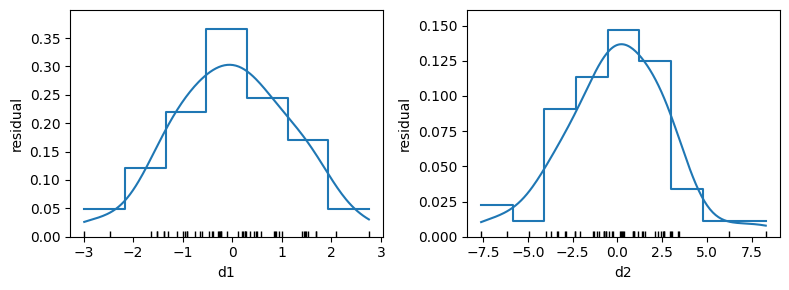

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, variable in zip(axes, ['d1', 'd2']):
    predicted = (
        smf.ols(f"{variable} ~ x", data=comparison)
        .fit()
        .predict()
    )
    actual = comparison[variable]
    residuals = predicted - actual

    # Plot histogram with KDE
    sns.histplot(residuals, kde=True, stat="density", ax=ax, element="step", fill=False)

    # Add rug separately
    sns.rugplot(residuals, ax=ax, color='black')

    ax.set_xlabel(variable)
    ax.set_ylabel("residual")

fig.tight_layout()


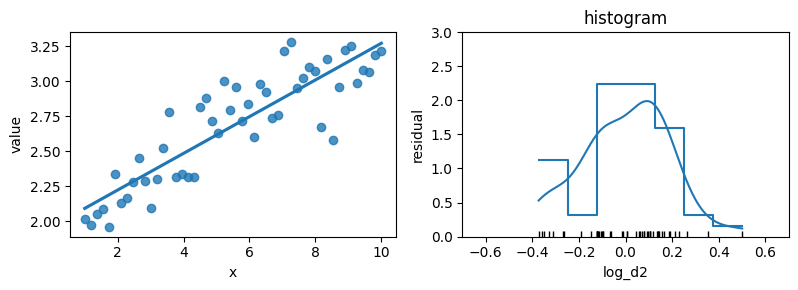

In [89]:
# Create DataFrame with log-transformed target
magic = pd.DataFrame({
    "log_d2": np.log(comparison['d2']),
    "x": x
})

# Melt for plotting multiple variables (if needed)
melted = pd.melt(magic, id_vars=['x'])

# Set up side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# First plot: regression line
sns.regplot(x='x', y='value', data=melted, ci=None, ax=ax1)

# Fit and compute residuals
predicted = smf.ols("log_d2 ~ x", data=magic).fit().predict()
actual = magic['log_d2']
residuals = predicted - actual

# Second plot: residual distribution (modern form)
sns.histplot(residuals, kde=True, stat="density", ax=ax2, element="step", fill=False)
sns.rugplot(residuals, ax=ax2, color="black")

# Formatting the residual plot
ax2.set_title('histogram')
ax2.set_xlim(-0.7, 0.7)
ax2.set_ylim(0, 3)
ax2.set_ylabel('residual')

fig.tight_layout()


In [91]:
# Generate input values and noise
x = np.linspace(1, 8, 100)
n1 = np.random.normal(size=x.shape)
n2 = x * np.random.normal(size=x.shape)

# Create various synthetic relationships
mystery = {
    'm1': 5 + n1,
    'm2': 5 + n2,
    'm3': x + n1,
    'm4': x + n2,
    'm5': np.log2(x) + n1,
    'm6': np.log2(x) + n2,
    'm7': np.exp2(x + n1),
    'm8': np.exp2(x + n2)
}

# Construct DataFrame
mystery_df = pd.DataFrame(mystery)
mystery_df['x'] = x